In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

print("Setup successful!")

Setup successful!


In [15]:
data = pd.read_csv("kolkata_population.csv")

In [16]:
data

,Year,Population
0,1901,1009853
1,1911,1117966
2,1921,1158497
3,1931,1289461
4,1941,2352399
5,1951,2956475
6,1961,3351250
7,1971,3727020
8,1981,4126846
9,1991,4399819


In [17]:
data.columns

Index(['Year', 'Population   '], dtype='object')

In [18]:
data.columns = data.columns.str.strip()

In [19]:
years = data["Year"].tolist()
population = data["Population"].tolist()

In [20]:
# Calculating Increment per decade

increments = []

for i in range(1, len(population)):
    increase = population[i] - population[i-1]
    increments.append(increase)

increments

[108113,
 40531,
 130964,
 1062938,
 604076,
 394775,
 375770,
 399826,
 272973,
 173057,
 -76182]

In [26]:
# Avg increment

avg_increase = np.mean(increments)

avg_increase # this is the "i" in the arithmetic progression equation

np.float64(316985.54545454547)

# Arithmetic Progression method

### P_n = P_0 + ni

where,

P_0 = Base Population,
P_n = Forecasted population after n decades from base population,
n = No of decades,
i = Arithmatic mean of population increase


In [58]:
# Arithmetical Progression method

base_population = population[-1]  # last year's population (P_0)
last_year = years[-1]  # in this case this is 2011

In [59]:
def arithmetic_forecast(target_year):

    n = (target_year - last_year)/10
    future_population = base_population + n * avg_increase

    return future_population

In [60]:
arithmetic_forecast(2021)

np.float64(4813679.545454546)

In [61]:
arithmetic_forecast(2031)

np.float64(5130665.090909091)

In [62]:
arithmetic_forecast(2041)

np.float64(5447650.636363637)

# Geometric Progression method

### P_n = P_0(1 + r/100)^n

where,

P_0 = Base Population,
P_n = Forecasted population after n decades from base population,
n = No of decades,
r = Percentage increase in population or growth rate

In [ ]:
percent_inc = []

for i in range(1, len(population)):

    r = ((population[i] - population[i-1])/population[i-1]) * 100

    percent_inc.append(r)

percent_inc 

[10.705815598904,
 3.6254233134102467,
 11.304647314580874,
 82.43273739958013,
 25.679147117474542,
 13.352894917088761,
 11.212831033196569,
 10.72776641928404,
 6.614567153705275,
 3.933275437012295,
 -1.6659537673884006]

In [ ]:
avg_percent = np.mean(percent_inc)

avg_percent # this is "r"

np.float64(16.17483199425894)

In [37]:
def geometric_forecast(target_year):
    n = (target_year - last_year)/10
    
    future_population = base_population * (1 + avg_percent/100)**n

    return future_population

In [40]:
geometric_forecast(2021)

np.float64(5224026.699795922)

In [41]:
arithmetic_forecast(2031)

np.float64(5130665.090909091)

In [42]:
arithmetic_forecast(2041)

np.float64(5447650.636363637)

Comparison b/w Arithmetic Progression and Geometric Progression

In [101]:
future_years = [2021, 2031, 2041, 2051, 2061, 2071, 2081, 2091, 2101, 2111, 2121, 2131, 2141, 2151, 2161, 2171, 2181, 2191, 2201, 2211, 2221, 2231, 2241, 2251]

arith_vals = [arithmetic_forecast(year) for year in future_years]

geo_vals = [geometric_forecast(year) for year in future_years]

In [102]:
comparison = pd.DataFrame(
    {
        "Year": future_years,
        "Arithmetic Method": arith_vals,
        "Geometric Method": geo_vals
    }
)

comparison

,Year,Arithmetic Method,Geometric Method
0,2021,4.813680e+06,5.224027e+06
1,2031,5.130665e+06,6.069004e+06
2,2041,5.447651e+06,7.050655e+06
3,2051,5.764636e+06,8.191087e+06
4,2061,6.081622e+06,9.515982e+06
5,2071,6.398607e+06,1.105518e+07
6,2081,6.715593e+06,1.284333e+07
7,2091,7.032578e+06,1.492072e+07
8,2101,7.349564e+06,1.733412e+07
9,2111,7.666549e+06,2.013789e+07


In [103]:
comparison["Difference"] = comparison["Geometric Method"] - comparison["Arithmetic Method"]

In [104]:
comparison

,Year,Arithmetic Method,Geometric Method,Difference
0,2021,4.813680e+06,5.224027e+06,4.103472e+05
1,2031,5.130665e+06,6.069004e+06,9.383392e+05
2,2041,5.447651e+06,7.050655e+06,1.603005e+06
3,2051,5.764636e+06,8.191087e+06,2.426451e+06
4,2061,6.081622e+06,9.515982e+06,3.434360e+06
5,2071,6.398607e+06,1.105518e+07,4.656569e+06
6,2081,6.715593e+06,1.284333e+07,6.127739e+06
7,2091,7.032578e+06,1.492072e+07,7.888141e+06
8,2101,7.349564e+06,1.733412e+07,9.984557e+06
9,2111,7.666549e+06,2.013789e+07,1.247134e+07


<function matplotlib.pyplot.show(close=None, block=None)>

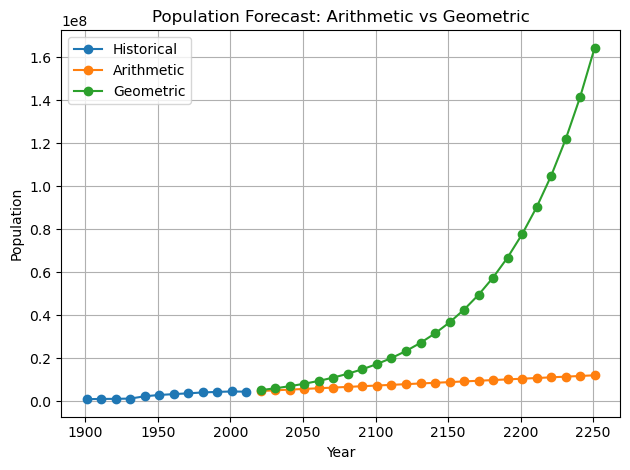

In [105]:
plt.figure()

plt.plot(years, population, marker='o', label="Historical")

plt.plot(comparison["Year"], comparison["Arithmetic Method"], marker='o', label="Arithmetic")

plt.plot(comparison["Year"], comparison["Geometric Method"], marker='o', label="Geometric")

plt.xlabel("Year")
plt.ylabel("Population")
plt.title("Population Forecast: Arithmetic vs Geometric")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show

### Inference:
    The arithmetic increase method assumes that population grows by a constant number of people each decade, resulting in a linear growth pattern.
    The geometric increase method assumes a constant percentage growth rate, producing exponential population growth.
    As seen in the graph, the geometric method predicts a higher population than the arithmetic method in future decades.

## Machine Learning Prediction

In [106]:
x = np.array(years).reshape(-1,1)
y = np.array(population) 

In [107]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [108]:
future_years = np.array([2021, 2031, 2041, 2051, 2061, 2071, 2081, 2091, 2101, 2111, 2121, 2131, 2141, 2151, 2161, 2171, 2181, 2191, 2201, 2211, 2221, 2231, 2241, 2251]).reshape(-1,1)
model.predict(future_years)

array([ 5399117.34848484,  5786684.68414919,  6174252.01981352,
        6561819.35547785,  6949386.69114219,  7336954.02680653,
        7724521.36247087,  8112088.6981352 ,  8499656.03379953,
        8887223.36946388,  9274790.70512821,  9662358.04079254,
       10049925.37645687, 10437492.7121212 , 10825060.04778555,
       11212627.38344988, 11600194.71911421, 11987762.05477855,
       12375329.39044289, 12762896.72610722, 13150464.06177156,
       13538031.39743589, 13925598.73310024, 14313166.06876457])

In [109]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree = 2)

x_poly = poly.fit_transform(x)

In [110]:
poly_model = LinearRegression()

In [111]:
poly_model.fit(x_poly, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [112]:
future_poly = poly.transform(future_years)

poly_forecast = poly_model.predict(future_poly)

In [140]:
year_range = np.linspace(min(years), 2251, 350).reshape(-1,1)

In [141]:
linear_curve = model.predict(year_range)

In [142]:
year_range_poly = poly.transform(year_range)

poly_curve = poly_model.predict(year_range_poly)

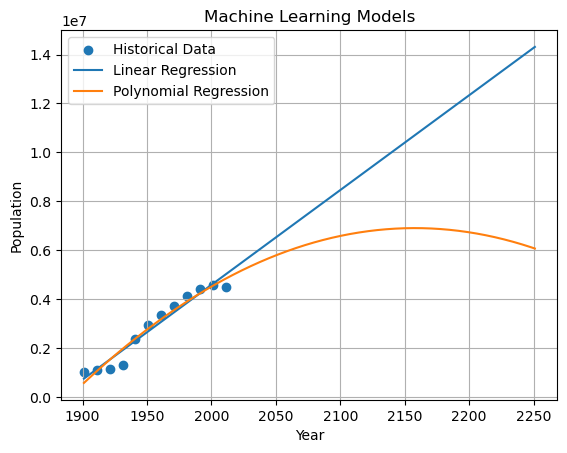

In [143]:
plt.figure()

# historical data
plt.scatter(years, population, label="Historical Data")

# linear regression trend
plt.plot(year_range, linear_curve, label="Linear Regression")

# polynomial regression trend
plt.plot(year_range, poly_curve, label="Polynomial Regression")

plt.xlabel("Year")
plt.ylabel("Population")

plt.title("Machine Learning Models")

plt.legend()
plt.grid(True)

plt.show()

In [144]:
# Model evaluation

from sklearn.metrics import r2_score, mean_absolute_error

In [145]:
linear_pred = model.predict(x)
poly_pred = poly_model.predict(x_poly)

In [146]:
linear_r2 = r2_score(y, linear_pred)
poly_r2 = r2_score(y, poly_pred)

In [147]:
print("Linear Regression R^2 value:", linear_r2)
print("Polynomial Regression R^2 value:", poly_r2)

Linear Regression R^2 value: 0.9477778682552349
Polynomial Regression R^2 value: 0.9532117308299346


In [151]:
# MAE

linear_mae = mean_absolute_error(y, linear_pred)
poly_mae = mean_absolute_error(y, poly_pred)

print("Linear Regression MAE:", linear_mae)
print("Polynomial Regression MAE:", poly_mae)

Linear Regression MAE: 261728.44425019497
Polynomial Regression MAE: 235918.98934422433


In [152]:
import pandas as pd

evaluation = pd.DataFrame({
    
    "Model": ["Linear Regression","Polynomial Regression"],
    
    "R^2 Score": [linear_r2, poly_r2],
    
    "MAE": [linear_mae, poly_mae]
})

evaluation

,Model,R^2 Score,MAE
0,Linear Regression,0.947778,261728.444250
1,Polynomial Regression,0.953212,235918.989344


### Inference:

    Polynomial regression provides a slightly better fit to historical population
    data compared to linear regression, as shown by a higher R² score and lower
    mean absolute error.

## Forecast Comparison

In [153]:
future_years = [2021, 2031, 2041, 2051, 2061, 2071, 2081, 2091, 2101, 2111, 2121, 2131, 2141, 2151, 2161, 2171, 2181, 2191, 2201, 2211, 2221, 2231, 2241, 2251]


arith_values = [arithmetic_forecast(y) for y in future_years]
geo_values = [geometric_forecast(y) for y in future_years]

future_arr = np.array(future_years).reshape(-1, 1)
linear_forecast = model.predict(future_arr)

future_poly = poly.transform(future_arr)
poly_forecast = poly_model.predict(future_poly)

In [154]:
comparison_final = pd.DataFrame({

    "Year": future_years,

    "Arithmetic": arith_values,

    "Geometric": geo_values,

    "Linear Regression": linear_forecast,

    "Polynomial Regression": poly_forecast
})

comparison_final

,Year,Arithmetic,Geometric,Linear Regression,Polynomial Regression
0,2021,4.813680e+06,5.224027e+06,5.399117e+06,5.107744e+06
1,2031,5.130665e+06,6.069004e+06,5.786685e+06,5.360831e+06
2,2041,5.447651e+06,7.050655e+06,6.174252e+06,5.594707e+06
3,2051,5.764636e+06,8.191087e+06,6.561819e+06,5.809371e+06
4,2061,6.081622e+06,9.515982e+06,6.949387e+06,6.004824e+06
5,2071,6.398607e+06,1.105518e+07,7.336954e+06,6.181066e+06
6,2081,6.715593e+06,1.284333e+07,7.724521e+06,6.338096e+06
7,2091,7.032578e+06,1.492072e+07,8.112089e+06,6.475915e+06
8,2101,7.349564e+06,1.733412e+07,8.499656e+06,6.594522e+06
9,2111,7.666549e+06,2.013789e+07,8.887223e+06,6.693918e+06


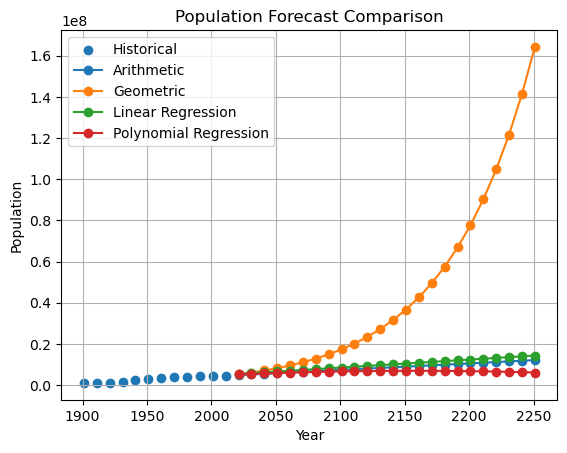

In [155]:
plt.figure()

# historical data
plt.scatter(years, population, label="Historical")

# arithmetic
plt.plot(future_years, arith_values, marker='o', label="Arithmetic")

# geometric
plt.plot(future_years, geo_values, marker='o', label="Geometric")

# linear regression
plt.plot(future_years, linear_forecast, marker='o', label="Linear Regression")

# polynomial regression
plt.plot(future_years, poly_forecast, marker='o', label="Polynomial Regression")

plt.xlabel("Year")
plt.ylabel("Population")

plt.title("Population Forecast Comparison")

plt.legend()
plt.grid(True)

plt.show()

## Final Insight

Arithmetic and geometric methods are traditional civil engineering
forecasting techniques.

Machine learning models learn population trends directly from data.

Polynomial regression often captures population growth trends
better than simple linear regression.